In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import torch.nn as nn 
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random

In [7]:
%load_ext autoreload
%autoreload 2

from metadata_fetcher import MetadataTracker

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
class SpotifySequenceDataset(Dataset):
    def __init__(self, history_csv, master_db_csv, max_seq_length=10, mode='dpo'):
        self.max_seq_length = max_seq_length
        self.mode = mode
        
        # 1. Build the in-memory feature dictionary
        self.feature_lookup = self._build_feature_dict(master_db_csv)
        
        # 2. Process the raw history
        history_df = pd.read_csv(history_csv)
        sessions = self._chunk_sessions(history_df)
        nip_data, dpo_data = self._extract_training_data(sessions)
        
        # 3. Store only the data requested by the mode
        self.data = dpo_data if mode == 'dpo' else nip_data
        print(f"Dataset initialized in {mode.upper()} mode with {len(self.data)} samples.")

    def _build_feature_dict(self, master_db_csv):
        """Converts raw Master DB into a dictionary of scaled PyTorch tensors dynamically."""
        print("Loading Master DB and scaling features...")
        
        # 1. low_memory=False stops Pandas from guessing data types chunk-by-chunk (fixes the warning)
        df = pd.read_csv(master_db_csv, low_memory=False) 
        
        feature_cols = ['danceability', 'energy', 'key', 'loudness', 'mode', 
                        'speechiness', 'acousticness', 'instrumentalness', 
                        'liveness', 'valence', 'tempo', 'time_signature']
        
        # --- 2. BULLETPROOFING: Sanitize all data before it touches the math ---
        for col in feature_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
                
        df[feature_cols] = df[feature_cols].fillna(-1.0)
        
        # --- 3. DYNAMIC IN-MEMORY SCALING ---
        scaler = MinMaxScaler()
        cols_to_scale = ['loudness', 'tempo']
        
        for col in cols_to_scale:
            if col in df.columns:
                valid_mask = df[col] != -1.0
                real_values = df.loc[valid_mask, [col]]
                
                if not real_values.empty:
                    df.loc[valid_mask, col] = scaler.fit_transform(real_values)
                
        # --- 4. VECTORIZED TENSOR CONVERSION ---
        print("Converting to PyTorch tensors...")
        track_ids = df['id'].values
        features_matrix = df[feature_cols].values.astype(np.float32)
        
        feature_dict = {
            t_id: torch.from_numpy(feat) 
            for t_id, feat in zip(track_ids, features_matrix) 
            if pd.notna(t_id) 
        }
            
        self.scaler = scaler 
        print(f"Success: Built dictionary for {len(feature_dict)} tracks.")
        return feature_dict

    def _chunk_sessions(self, history_df):
        """
        Vectorized sessionization of listening history based on 
        20-minute gaps or context changes.
        """
        # 1. Ensure absolute chronological order
        df = history_df.copy()
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values('timestamp').reset_index(drop=True)
    
        # 2. Calculate the time gap between each song and the one before it
        time_gaps = df['timestamp'].diff()
    
        # 3. Check if the context_uri changed from the previous row
        context_changed = df['context_uri'] != df['context_uri'].shift(1)
    
        # 4. A new session starts IF the gap is > 20 mins OR the context changed
        is_new_session = (time_gaps > pd.Timedelta(minutes=20)) | context_changed
    
        # 5. Create a unique ID for each session using cumulative sum
        df['session_id'] = is_new_session.cumsum()
    
        # 6. Group the dataframe into a list of smaller session dataframes
        sessions = [group for _, group in df.groupby('session_id')]
    
        print(f"Divided {len(df)} tracks into {len(sessions)} distinct listening sessions.")
        return sessions
    
    def _extract_training_data(self, sessions, max_seq_length=10):
        """
        Slides a window across each session to simultaneously extract 
        Next-Item Prediction (NIP) flows and Direct Preference Optimization (DPO) pairs.
        """
        nip_dataset = []
        dpo_dataset = []
        
        for session_df in sessions:
            current_context = []
            pending_negatives = []
            
            # Loop through the session chronologically
            for row in session_df.itertuples():
                track_id = row.track_id
                
                # 1. The Explicit Rejection (Skip)
                if row.completion_rate < 0.10:
                    pending_negatives.append(track_id)
                    
                # 2. The Good Path (Track Accepted)
                elif row.completion_rate > 0.50:
                    
                    if len(current_context) > 0:
                        
                        # NIP TARGET
                        nip_dataset.append({
                            'context': list(current_context),
                            'target': track_id
                        })
                        
                        # DPO TARGETS
                        if pending_negatives:
                            for negative_track in pending_negatives:
                                dpo_dataset.append({
                                    'context': list(current_context),
                                    'positive': track_id,
                                    'negative': negative_track
                                })
                                
                    pending_negatives = []
                    
                    current_context.append(track_id)
                    
                    if len(current_context) > max_seq_length:
                        current_context.pop(0)
                
                # 3. Mediocre Track
                else:
                    # Completion is between 10% and 50%
                    current_context = []
                    pending_negatives = []
                    
        print(f"Extracted {len(nip_dataset)} Next-Item (NIP) sequences.")
        print(f"Extracted {len(dpo_dataset)} Preference (DPO) pairs.")
        
        return nip_dataset, dpo_dataset
    
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        """Retrieves a single training example and converts it to Tensors."""
        sample = self.data[idx]
        context_ids = sample['context']
        
        # 1. Determine how many songs are actually in the context
        seq_len = len(context_ids)
        
        num_features = 12 
        
        # 2. Create the blank Left-Padded matrix (Size: 10 rows x 12 columns)
        context_tensor = torch.zeros((self.max_seq_length, num_features), dtype=torch.float32)
        
        # 3. Fill the matrix from the right side
        for i, track_id in enumerate(context_ids):
            padded_idx = self.max_seq_length - seq_len + i 
            
            if track_id in self.feature_lookup:
                context_tensor[padded_idx] = self.feature_lookup[track_id]
            else:
                context_tensor[padded_idx] = torch.full((num_features,), -1.0)
                
        # 4. Fetch the targets
        if self.mode == 'dpo':
            pos_features = self.feature_lookup.get(sample['positive'], torch.full((num_features,), -1.0))
            neg_features = self.feature_lookup.get(sample['negative'], torch.full((num_features,), -1.0))
            return context_tensor, pos_features, neg_features
            
        elif self.mode == 'nip':
            # 1. The True Target (Positive)
            pos_features = self.feature_lookup.get(sample['target'], torch.full((num_features,), -1.0))
            
            # 2. Negative Sampling (Pick a random real song)
            all_track_ids = list(self.feature_lookup.keys())
            random_neg_id = random.choice(all_track_ids)
            
            while random_neg_id == sample['target']:
                random_neg_id = random.choice(all_track_ids)
                
            neg_features = self.feature_lookup.get(random_neg_id, torch.full((num_features,), -1.0))
            
            return context_tensor, pos_features, neg_features

In [9]:
class SpotifySASRec(nn.Module):
    def __init__(self, num_features=12, d_model=128, max_seq_length=10):
        super().__init__()
        self.max_seq_length = max_seq_length
        self.feature_proj = nn.Linear(num_features, d_model)
        self.pos_emb = nn.Embedding(max_seq_length, d_model)
        self.attention_block = nn.TransformerEncoderLayer(d_model=d_model, nhead=8, batch_first=True)
        
    def forward(self, context_features, causal_mask):
        # 1. Process the context sequence
        x = self.feature_proj(context_features)
        positions = torch.arange(x.size(1), device=x.device)
        x = x + self.pos_emb(positions)
        
        # 2. Extract the "Present Moment"
        transformer_out = self.attention_block(x, src_mask=causal_mask)
        current_vibe = transformer_out[:, -1, :] # Shape: [Batch, 128]
        return current_vibe
    
    def score_candidates(self, current_vibe, target_features):
        # 1. Process the candidate track
        target_vibe = self.feature_proj(target_features) # Shape: [Batch, 128]
        
        # 2. The Match: Dot product between the Context and the Target
        scores = (current_vibe * target_vibe).sum(dim=-1) 
        return scores

--- Loading master_track_table.csv ---


C:\Users\Admin\AppData\Local\Temp\ipykernel_4420\392239554.py:10: DtypeWarning: Columns (1,2,3,4,5,23,25,26,28,29,30,32,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FILE_PATH)


Total Tracks: 1374037
Tracks with valid audio features: 1374037


--- Missing vs. Zero Values ---
                  Missing (NaN)  Exactly 0.0 Percentage 0.0
danceability                  0         2934          0.21%
energy                        0          298          0.02%
loudness                      0            0           0.0%
speechiness               85000         2934          0.21%
acousticness              85000          836          0.06%
instrumentalness              0       257597         18.75%
liveness                  85000          815          0.06%
valence                   85000         4041          0.29%
tempo                         0         2933          0.21%

Generating Distribution Histograms...

Generating Correlation Heatmap...


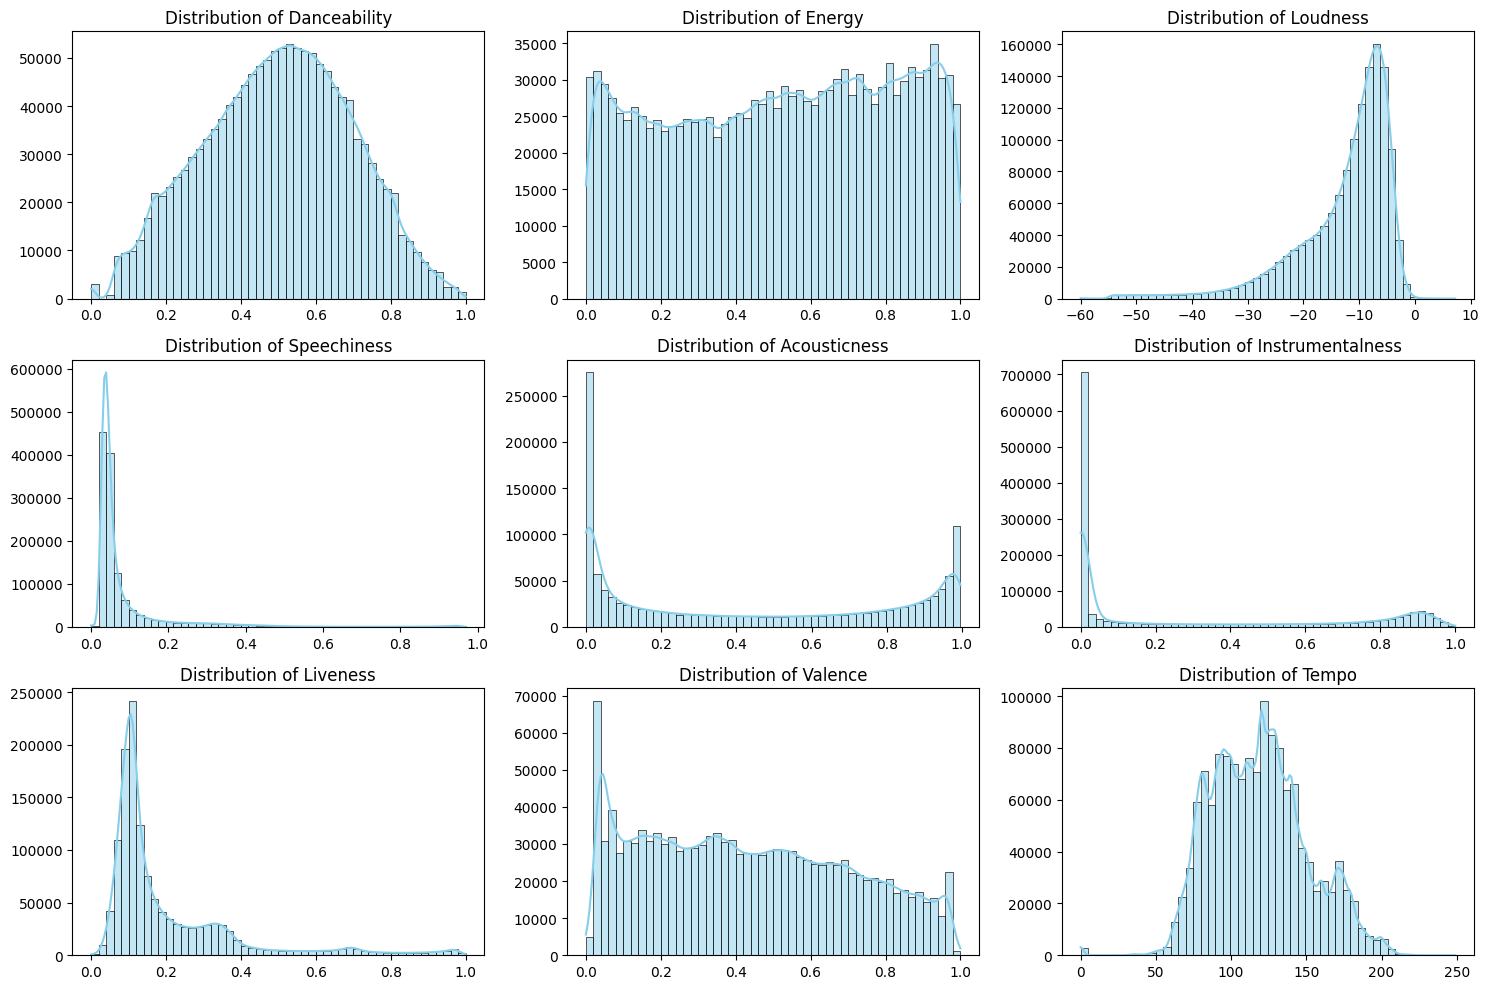

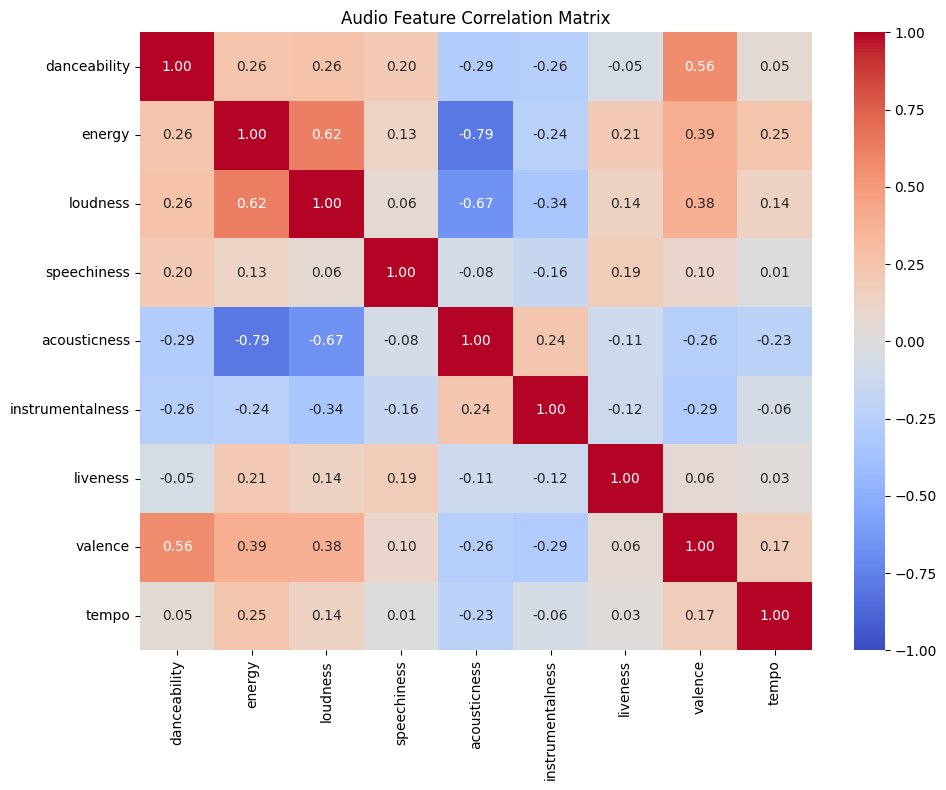

In [ ]:
# --- 1. Load the Data ---
FILE_PATH = "master_track_table.csv" 

if not os.path.exists(FILE_PATH):
    print(f"File {FILE_PATH} not found. Please check the path.")
    exit()

print(f"--- Loading {FILE_PATH} ---")
df = pd.read_csv(FILE_PATH)

# Isolate just the numerical audio features for analysis
features = ['danceability', 'energy', 'loudness', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# Filter the dataframe to only include tracks that actually have these features 
valid_df = df[df['danceability'] != -1.0].copy()

print(f"Total Tracks: {len(df)}")
print(f"Tracks with valid audio features: {len(valid_df)}\n")

# --- 2. Missing Values & Averages ---
print("\n--- Missing vs. Zero Values ---")
zero_counts = valid_df[features].eq(0.0).sum()
missing_counts = valid_df[features].isnull().sum()

summary_df = pd.DataFrame({
    'Missing (NaN)': missing_counts,
    'Exactly 0.0': zero_counts,
    'Percentage 0.0': (zero_counts / len(valid_df) * 100).round(2).astype(str) + '%'
})
print(summary_df)

# --- 3. Visualizing Distributions (Histograms) ---
print("\nGenerating Distribution Histograms...")
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i) # Creates a 3x3 grid of graphs
    sns.histplot(valid_df[feature], bins=50, kde=True, color='skyblue')
    plt.title(f'Distribution of {feature.capitalize()}')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
#plt.savefig("feature_distributions.png")
#print("Saved histograms to 'feature_distributions.png'")

# --- 4. The Correlation Heatmap ---
print("\nGenerating Correlation Heatmap...")
plt.figure(figsize=(10, 8))
# Calculate how much every feature moves in relation to every other feature
correlation_matrix = valid_df[features].corr()

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Audio Feature Correlation Matrix")
plt.tight_layout()
#plt.savefig("feature_correlations.png")
#print("Saved heatmap to 'feature_correlations.png'")

In [10]:
def generate_causal_mask(seq_length):
    mask = torch.tril(torch.ones(seq_length, seq_length))
    mask = mask.masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
    return mask

def dpo_loss(pos_scores, neg_scores):
    """
    Calculates the Direct Preference Optimization loss.
    Forces the model to rank the Positive track higher than the Negative track.
    """
    # 1. Calculate the raw difference in vibes
    difference = pos_scores - neg_scores
    
    # 2. Apply the stable Log-Sigmoid to get the loss penalty
    loss = -F.logsigmoid(difference).mean()
    
    return loss

def apply_heuristics(base_scores, candidate_ids, metadata_tracker, device):
    """
    Modifies the Transformer's raw scores using fatigue, recency, and void rules.
    """
    plays = torch.tensor([metadata_tracker.get(c_id, {}).get('play_count', 0.0) for c_id in candidate_ids], device=device)
    skips = torch.tensor([metadata_tracker.get(c_id, {}).get('skip_count', 0.0) for c_id in candidate_ids], device=device)
    days_old = torch.tensor([metadata_tracker.get(c_id, {}).get('days_since_added', 365.0) for c_id in candidate_ids], device=device)
    
    # 2. Reduce score slightly for every time the song played
    fatigue_weight = 0.05
    adjusted_scores = base_scores - (plays * fatigue_weight)
    
    # 3. Boost the score of newly added tracks
    recency_weight = 1.0 
    adjusted_scores = adjusted_scores + (recency_weight / (days_old + 1.0))
    
    # Identify songs that have been skipped at least once
    in_the_void = skips > 0
    
    # Create a random chance for a voided song to be given a second chance
    escape_chance = torch.rand(in_the_void.size(), device=device) < 0.05
    
    # A song is banned if it is in the void and it didn't win the escape chance
    actual_ban_mask = in_the_void & ~escape_chance
    
    # Apply a penalty so it drops to the bottom
    adjusted_scores[actual_ban_mask] -= 1000.0
    
    return adjusted_scores

In [11]:
def train_model(dataset, model, epochs=5, batch_size=32, learning_rate=0.001):
    
    # 1. The DataLoader automatically groups the dataset into batches
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # 2. The Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # 3. Generate the causal mask 
    causal_mask = generate_causal_mask(model.max_seq_length)
    
    model.train()
    
    for epoch in range(epochs):
        total_loss = 0.0
        
        for batch in dataloader:
            # -- Step A: Unpack the batch --
            context_tensor, pos_features, neg_features = batch
            
            # -- Step B: The Forward Pass --
            current_vibe = model(context_tensor, causal_mask)
            pos_scores = model.score_candidates(current_vibe, pos_features)
            neg_scores = model.score_candidates(current_vibe, neg_features)
            
            # -- Step C: Calculate the Loss --
            loss = dpo_loss(pos_scores, neg_scores)
            
            # -- Step D: Update the weights --
            optimizer.zero_grad() 
            loss.backward()       
            optimizer.step()     
            
            total_loss += loss.item()
            
        print(f"Epoch {epoch+1} | Average Loss: {total_loss / len(dataloader):.4f}")

In [12]:
EPOCHS = 5
BATCH_SIZE = 32
LEARNING_RATE = 0.001
MAX_SEQ_LENGTH = 10
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


dataset = SpotifySequenceDataset(history_csv='sensitive_info/spotify_listening_history.csv', master_db_csv='master_track_table.csv', max_seq_length=MAX_SEQ_LENGTH, mode='nip')
model = SpotifySASRec(num_features=12, d_model=128, max_seq_length=MAX_SEQ_LENGTH)
train_model(dataset=dataset, model=model, epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE)

Loading Master DB and scaling features...
Converting to PyTorch tensors...
Success: Built dictionary for 1374037 tracks.
Divided 1823 tracks into 21 distinct listening sessions.
Extracted 1751 Next-Item (NIP) sequences.
Extracted 23 Preference (DPO) pairs.
Dataset initialized in NIP mode with 1751 samples.
Epoch 1 | Average Loss: 2.0964
Epoch 2 | Average Loss: 0.2581
Epoch 3 | Average Loss: 0.1631
Epoch 4 | Average Loss: 0.1802
Epoch 5 | Average Loss: 0.1921


In [13]:
DEVICE = 'cpu'
tracker = MetadataTracker()

def evaluate_hit_at_10(dataset, model, num_fakes=99):
    print(f"--- Running Hit@10 Evaluation (1 True + {num_fakes} Fakes) ---")

    model.eval() 
    hits = 0
    
    test_size = min(500, len(dataset))
    all_track_ids = list(dataset.feature_lookup.keys())
    
    with torch.no_grad():
        for i in range(test_size):
            context_tensor, _, _ = dataset[i] 
            true_track_id = dataset.data[i]['target']
            
            # Build the 100-track candidate list (True target is always at index 0)
            candidates = [true_track_id]
            while len(candidates) < num_fakes + 1:
                fake_id = random.choice(all_track_ids)
                if fake_id not in candidates:
                    candidates.append(fake_id)
                    
            # Stack the features for all 100 candidates into a single block
            num_features = 12
            candidate_features = torch.stack([
                dataset.feature_lookup.get(c_id, torch.full((num_features,), -1.0)) 
                for c_id in candidates
            ]).to(DEVICE)
            
            # Add a batch dimension to the context and push to GPU/CPU
            context_tensor = context_tensor.unsqueeze(0).to(DEVICE)
            causal_mask = generate_causal_mask(model.max_seq_length).to(DEVICE)
            
            # --- THE INFERENCE ENGINE ---
            current_vibe = model(context_tensor, causal_mask) # Shape: [1, 128]
            
            target_vibes = model.feature_proj(candidate_features) # Shape: [100, 128]
            
            raw_scores = (current_vibe.squeeze(0) * target_vibes).sum(dim=-1)
            
            final_scores = apply_heuristics(raw_scores, candidates, tracker.memory, DEVICE)

            _, top_10_indices = torch.topk(final_scores, 10)
            
            if 0 in top_10_indices:
                hits += 1
                
    hit_rate = (hits / test_size) * 100
    print(f"Hit@10 Score: {hit_rate:.2f}%")
    
    model.train() 

evaluate_hit_at_10(dataset, model)

--- Running Hit@10 Evaluation (1 True + 99 Fakes) ---
Hit@10 Score: 79.80%


In [12]:
dpo_dataset = SpotifySequenceDataset(
    history_csv='sensitive_info/spotify_listening_history.csv', 
    master_db_csv='master_track_table.csv', 
    max_seq_length=MAX_SEQ_LENGTH, 
    mode='dpo'
)

DPO_EPOCHS = 3
DPO_LEARNING_RATE = 0.0001

print("\n--- Phase 2: Fine-Tuning ---")
train_model(
    dataset=dpo_dataset, 
    model=model, 
    epochs=DPO_EPOCHS, 
    batch_size=BATCH_SIZE, 
    learning_rate=DPO_LEARNING_RATE
)

evaluate_hit_at_10(dataset, model)

Loading Master DB and scaling features...
Converting to PyTorch tensors...
Success: Built dictionary for 1374037 tracks.
Divided 1823 tracks into 21 distinct listening sessions.
Extracted 1751 Next-Item (NIP) sequences.
Extracted 23 Preference (DPO) pairs.
Dataset initialized in DPO mode with 23 samples.

--- Phase 2: Fine-Tuning ---
Epoch 1 | Average Loss: 1.1205
Epoch 2 | Average Loss: 1.1962
Epoch 3 | Average Loss: 0.6208
--- Running Hit@10 Evaluation (1 True + 99 Fakes) ---
Hit@10 Score: 83.00% (Random chance is 10.00%)
